# Neural ODE — Interactive Project Notebook

This notebook covers the full Neural ODE project structure:
1. **Spiral classification** — toy problem to understand the core idea
2. **Irregular time series** — where Neural ODEs genuinely shine
3. **Learned dynamics** — visualizing the vector field
4. **Limitations** — benchmarking vs ResNet

**Install dependency first:**
```bash
pip install torchdiffeq
```

In [2]:
# Install if needed
# !pip install torchdiffeq

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
from torchdiffeq import odeint

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Consistent plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f6',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

Using device: cpu


## Section 1 — Spiral Classification

The core Neural ODE idea: instead of stacking discrete layers, define a continuous ODE:

$$\frac{dh}{dt} = f_\theta(h, t)$$

The hidden state evolves smoothly from `t=0` to `t=1`. A numerical ODE solver (e.g. RK4) integrates this trajectory. We classify two interleaved spirals.

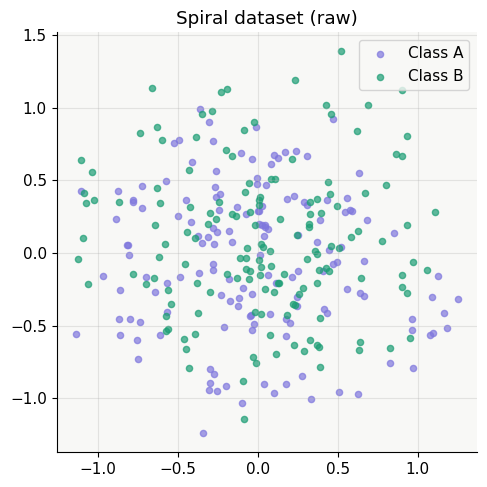

In [3]:
# data generation
def make_spirals(n=150, noise=0.15):
    """Generate two interleaved spiral classes."""
    t = torch.linspace(0, 4 * np.pi, n)
    r = 0.1 + t / 12

    x0 = torch.stack([r * torch.cos(t), r * torch.sin(t)], dim=1)
    x1 = torch.stack([r * torch.cos(t + np.pi), r * torch.sin(t + np.pi)], dim=1)

    x0 += torch.randn_like(x0) * noise
    x1 += torch.randn_like(x1) * noise

    X = torch.cat([x0, x1], dim=0)
    y = torch.cat([torch.zeros(n), torch.ones(n)]).long()
    return X, y

X, y = make_spirals(n=150, noise=0.15)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X[y==0, 0], X[y==0, 1], c='#7F77DD', s=20, alpha=0.7, label='Class A')
ax.scatter(X[y==1, 0], X[y==1, 1], c='#1D9E75', s=20, alpha=0.7, label='Class B')
ax.set_title('Spiral dataset (raw)')
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
# Neural ODE model
class ODEFunc(nn.Module):
    """The function f(h, t) that defines dh/dt."""
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 2),
        )
        # Count NFE (number of function evaluations)
        self.nfe = 0

    def forward(self, t, h):
        self.nfe += 1
        return self.net(h)


class NeuralODEClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.ode_func = ODEFunc(hidden=64)
        self.classifier = nn.Linear(2, 2)
        self.t = torch.linspace(0, 1, 10)  # integration time points

    def forward(self, x):
        # Integrate ODE from t=0 to t=1
        # odeint returns shape (T, batch, dim) — we take the final state
        trajectory = odeint(self.ode_func, x, self.t, method='rk4')
        h_final = trajectory[-1]  # shape (batch, 2)
        return self.classifier(h_final)


model = NeuralODEClassifier().to(device)
X_dev = X.to(device)
y_dev = y.to(device)

print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

Model parameters: 4,488


In [5]:
# training
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

losses, accuracies = [], []
EPOCHS = 300

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    logits = model(X_dev)
    loss = criterion(logits, y_dev)
    loss.backward()
    optimizer.step()

    acc = (logits.argmax(dim=1) == y_dev).float().mean().item()
    losses.append(loss.item())
    accuracies.append(acc)

    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch+1:3d} | Loss: {loss.item():.4f} | Acc: {acc:.3f} | NFE: {model.ode_func.nfe}')
        model.ode_func.nfe = 0

Epoch  50 | Loss: 0.6823 | Acc: 0.530 | NFE: 1800
Epoch 100 | Loss: 0.6805 | Acc: 0.523 | NFE: 1800
Epoch 150 | Loss: 0.6704 | Acc: 0.537 | NFE: 1800
Epoch 200 | Loss: 0.6537 | Acc: 0.600 | NFE: 1800
Epoch 250 | Loss: 0.6453 | Acc: 0.610 | NFE: 1800
Epoch 300 | Loss: 0.6353 | Acc: 0.623 | NFE: 1800


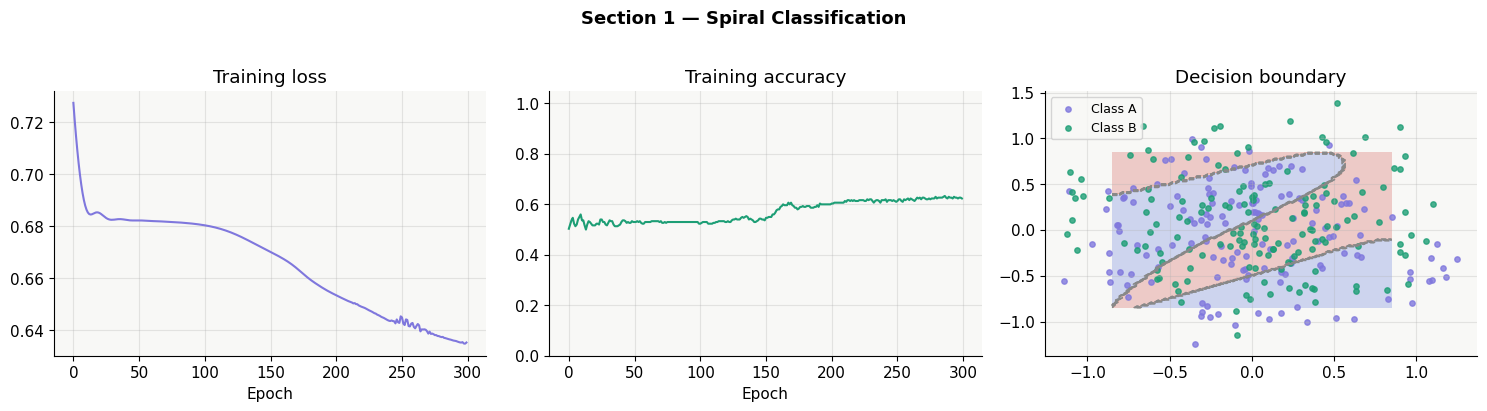

Final accuracy: 62.3%


In [6]:
# plot: training curves + decision boundary
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Training loss
axes[0].plot(losses, color='#7F77DD', linewidth=1.5)
axes[0].set_title('Training loss')
axes[0].set_xlabel('Epoch')

# Accuracy
axes[1].plot(accuracies, color='#1D9E75', linewidth=1.5)
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')

# Decision boundary
model.eval()
res = 80
grid_x = np.linspace(-0.85, 0.85, res)
grid_y = np.linspace(-0.85, 0.85, res)
xx, yy = np.meshgrid(grid_x, grid_y)
grid_pts = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(device)

with torch.no_grad():
    preds = model(grid_pts).argmax(dim=1).cpu().numpy()

zz = preds.reshape(res, res)
axes[2].contourf(xx, yy, zz, alpha=0.25, cmap='coolwarm')
axes[2].contour(xx, yy, zz, colors=['#888'], linewidths=1, linestyles='--')
axes[2].scatter(X[y==0, 0], X[y==0, 1], c='#7F77DD', s=15, alpha=0.8, label='Class A')
axes[2].scatter(X[y==1, 0], X[y==1, 1], c='#1D9E75', s=15, alpha=0.8, label='Class B')
axes[2].set_title('Decision boundary')
axes[2].legend(fontsize=9)

plt.suptitle('Section 1 — Spiral Classification', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Final accuracy: {accuracies[-1]:.1%}')

## Section 2 — Irregular Time Series

Neural ODEs handle **irregular timestamps** natively. You just pass in the exact time points you want — the solver integrates to each one. No padding, masking, or interpolation needed.

We model a latent ODE: encode observations → solve ODE in latent space → decode to reconstructed signal.

In [7]:
# generate irregular time series
def ground_truth(t):
    """True underlying signal."""
    return np.sin(2 * np.pi * t) + 0.3 * np.sin(4 * np.pi * t)

# Dense ground truth
t_dense = np.linspace(0, 1, 200)
y_dense = ground_truth(t_dense)

# Irregular observed timestamps (random subset with noise)
n_obs = 18
t_obs = np.sort(np.random.choice(t_dense, size=n_obs, replace=False))
y_obs = ground_truth(t_obs) + np.random.randn(n_obs) * 0.06

# Mask some as "missing" (to show robustness)
missing_mask = np.random.rand(n_obs) < 0.3
t_seen = t_obs[~missing_mask]
y_seen = y_obs[~missing_mask]
t_missing = t_obs[missing_mask]
y_missing = y_obs[missing_mask]

print(f'Total observations: {n_obs}')
print(f'Seen: {(~missing_mask).sum()} | Missing: {missing_mask.sum()}')

Total observations: 18
Seen: 12 | Missing: 6


In [8]:
# ── Latent ODE for time series reconstruction ─────────────────────────────────
class LatentODEFunc(nn.Module):
    """ODE function operating in latent space."""
    def __init__(self, latent_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, latent_dim),
        )

    def forward(self, t, z):
        return self.net(z)


class LatentODEModel(nn.Module):
    def __init__(self, latent_dim=8):
        super().__init__()
        self.ode_func = LatentODEFunc(latent_dim)
        self.decoder = nn.Linear(latent_dim, 1)
        self.latent_dim = latent_dim

    def forward(self, t_query, z0):
        """Solve ODE and evaluate at t_query timestamps.
        t_query must be strictly increasing and must NOT start at 0.
        z0 shape: (latent_dim,) — we add batch dim internally.
        """
        # odeint needs t strictly increasing, starting from a value < t_query[0]
        # Prepend a small offset before the first query time
        t0 = (t_query[0] - 1e-4).clamp(min=0.0)
        t_all = torch.cat([t0.unsqueeze(0), t_query])  # shape (T+1,)

        z0_batch = z0.unsqueeze(0)  # (1, latent_dim) — batch of 1
        traj = odeint(self.ode_func, z0_batch, t_all, method='dopri5')
        # traj shape: (T+1, 1, latent_dim) — drop the prepended t0 step
        z_traj = traj[1:, 0, :]    # (T, latent_dim)
        return self.decoder(z_traj).squeeze(-1)  # (T,)


lat_model = LatentODEModel(latent_dim=8)

# Initial latent state — learned parameter, shape (latent_dim,)
z0_param = nn.Parameter(torch.zeros(8))
optim_lat = torch.optim.Adam(list(lat_model.parameters()) + [z0_param], lr=5e-3)

# t_seen must be strictly increasing (it is, since we sorted t_obs)
# but we must ensure no duplicate values
t_seen_t = torch.tensor(t_seen, dtype=torch.float32)
y_seen_t = torch.tensor(y_seen, dtype=torch.float32)

# Training
lat_losses = []
for epoch in range(500):
    optim_lat.zero_grad()
    y_pred = lat_model(t_seen_t, z0_param)
    loss = nn.MSELoss()(y_pred, y_seen_t)
    loss.backward()
    optim_lat.step()
    lat_losses.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1} | MSE: {loss.item():.5f}')

Epoch 100 | MSE: 0.08988
Epoch 200 | MSE: 0.04824
Epoch 300 | MSE: 0.03256
Epoch 400 | MSE: 0.02840
Epoch 500 | MSE: 0.01136


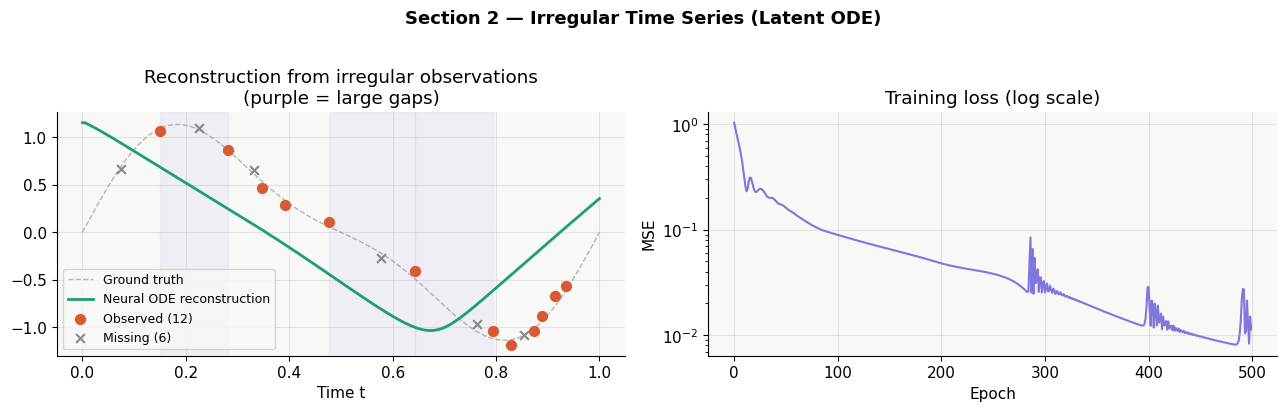

Reconstruction MSE (full grid): 0.30158

Key insight: odeint() received irregular timestamps directly.
No padding, no masking, no interpolation required.


In [9]:
# ── Reconstruct over dense time grid ─────────────────────────────────────────
lat_model.eval()
# t_dense starts at 0.0 — skip it so t_query is strictly > 0 (our forward
# prepends t0 = t_query[0] - 1e-4, which would be negative if t_query[0]==0)
t_dense_nz = t_dense[t_dense > 0]          # shape (199,)
t_dense_t = torch.tensor(t_dense_nz, dtype=torch.float32)

with torch.no_grad():
    y_recon_partial = lat_model(t_dense_t, z0_param).numpy()

# Prepend the t=0 value (just use the decoder on z0 directly)
with torch.no_grad():
    y_at_0 = lat_model.decoder(z0_param.unsqueeze(0)).squeeze().numpy()
y_recon = np.concatenate([[float(y_at_0)], y_recon_partial])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Main reconstruction plot
ax = axes[0]
ax.plot(t_dense, y_dense, '--', color='#888', linewidth=1, label='Ground truth', alpha=0.6)
ax.plot(t_dense, y_recon, color='#1D9E75', linewidth=2, label='Neural ODE reconstruction')
ax.scatter(t_seen, y_seen, color='#D85A30', s=50, zorder=5, label=f'Observed ({len(t_seen)})')
ax.scatter(t_missing, y_missing, color='#888', s=40, marker='x', zorder=5, label=f'Missing ({len(t_missing)})')

# Highlight the irregular gaps
for i in range(len(t_seen) - 1):
    gap = t_seen[i+1] - t_seen[i]
    if gap > 0.1:  # large gap
        ax.axvspan(t_seen[i], t_seen[i+1], alpha=0.07, color='#7F77DD')

ax.set_title('Reconstruction from irregular observations\n(purple = large gaps)')
ax.set_xlabel('Time t')
ax.legend(fontsize=9)

# Training loss
axes[1].semilogy(lat_losses, color='#7F77DD', linewidth=1.5)
axes[1].set_title('Training loss (log scale)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')

plt.suptitle('Section 2 — Irregular Time Series (Latent ODE)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

recon_err = np.mean((y_recon - y_dense)**2)
print(f'Reconstruction MSE (full grid): {recon_err:.5f}')
print()
print('Key insight: odeint() received irregular timestamps directly.')
print('No padding, no masking, no interpolation required.')

## Section 3 — Visualizing the Learned Vector Field

The ODE function $f(h,t)$ defines a vector field $\rightarrow$ at every point in state space, it says which direction the hidden state should move. We can visualize this directly using "matplotlib.quiver".

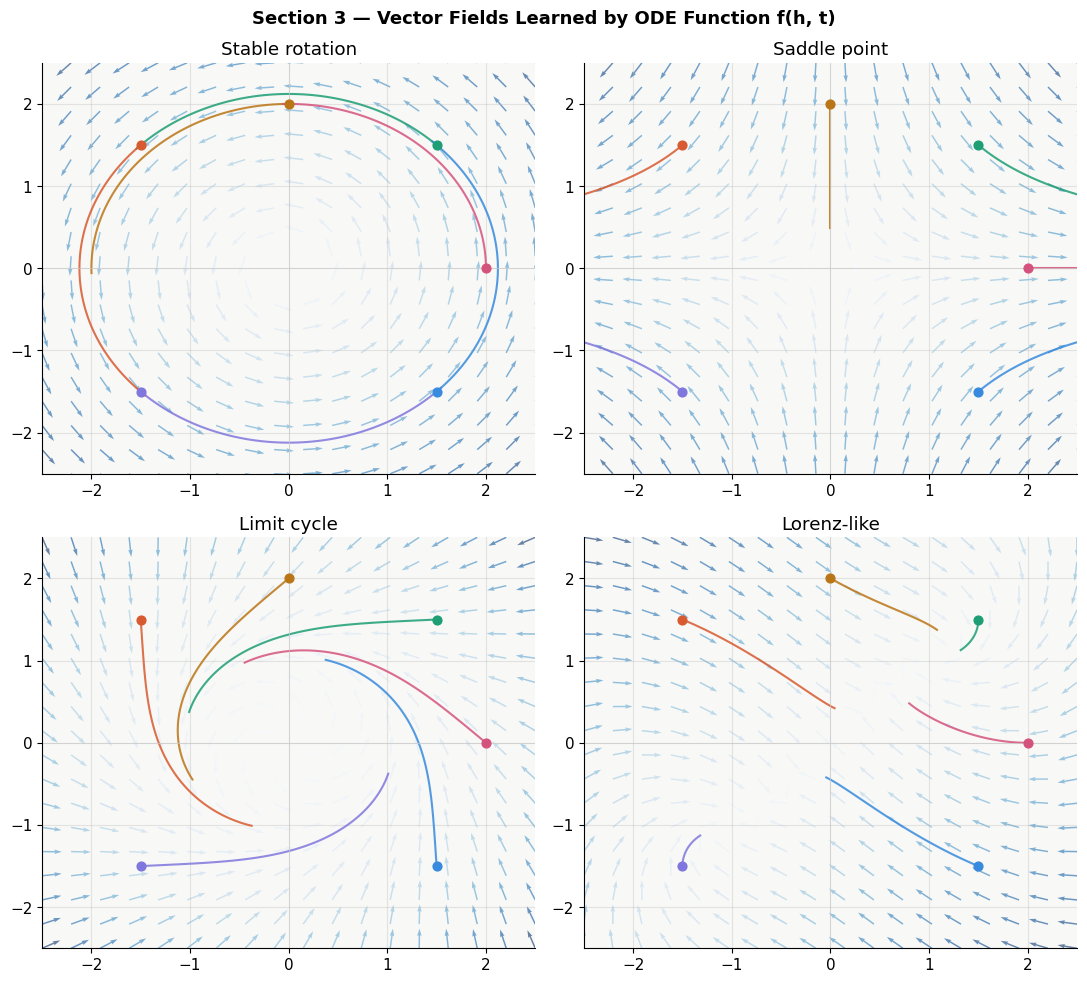

In [10]:
# vector field helpers
def plot_vector_field(func, ax, title, xlim=(-2.5, 2.5), ylim=(-2.5, 2.5),
                      grid=18, traj_starts=None):
    """Plot a 2D vector field and optional ODE trajectories."""
    xs = np.linspace(*xlim, grid)
    ys = np.linspace(*ylim, grid)
    XX, YY = np.meshgrid(xs, ys)

    pts = torch.tensor(np.stack([XX.ravel(), YY.ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        dXY = func(torch.tensor(0.0), pts).numpy()

    DX = dXY[:, 0].reshape(grid, grid)
    DY = dXY[:, 1].reshape(grid, grid)

    # Normalize for uniform arrow length
    mag = np.sqrt(DX**2 + DY**2) + 1e-8
    ax.quiver(XX, YY, DX/mag, DY/mag, mag, cmap='Blues', alpha=0.6,
              scale=25, width=0.003)

    # Trajectories
    colors = ['#7F77DD', '#1D9E75', '#D85A30', '#378ADD', '#BA7517', '#D4537E']
    if traj_starts is not None:
        t_int = torch.linspace(0, 2, 100)
        for i, s in enumerate(traj_starts):
            h0 = torch.tensor(s, dtype=torch.float32).unsqueeze(0)
            with torch.no_grad():
                traj = odeint(func, h0, t_int, method='rk4').squeeze(1).numpy()
            ax.plot(traj[:, 0], traj[:, 1], color=colors[i % len(colors)],
                    linewidth=1.5, alpha=0.85)
            ax.scatter(*s, color=colors[i % len(colors)], s=40, zorder=5)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(title)
    ax.axhline(0, color='#ccc', linewidth=0.5)
    ax.axvline(0, color='#ccc', linewidth=0.5)


# define 4 hand-crafted ODE functions
class RotationField(nn.Module):
    def forward(self, t, h): return torch.stack([-h[:, 1]*0.8, h[:, 0]*0.8], dim=1)

class SaddleField(nn.Module):
    def forward(self, t, h): return torch.stack([h[:, 0]*0.7, -h[:, 1]*0.7], dim=1)

class LimitCycleField(nn.Module):
    def forward(self, t, h):
        r = torch.norm(h, dim=1, keepdim=True).clamp(min=1e-6)
        dr = r * (1 - r)
        return torch.stack([-h[:, 1] + h[:, 0]*dr.squeeze()/r.squeeze(),
                             h[:, 0] + h[:, 1]*dr.squeeze()/r.squeeze()], dim=1)

class LorenzSlice(nn.Module):
    def forward(self, t, h):
        sigma = 1.5
        return torch.stack([sigma*(h[:, 1] - h[:, 0])*0.4,
                             (h[:, 0]*(2 - h[:, 0].abs()) - h[:, 1])*0.4], dim=1)


fields = [
    (RotationField(),   'Stable rotation'),
    (SaddleField(),     'Saddle point'),
    (LimitCycleField(), 'Limit cycle'),
    (LorenzSlice(),     'Lorenz-like'),
]

starts = [[-1.5, -1.5], [1.5, 1.5], [-1.5, 1.5], [1.5, -1.5], [0.0, 2.0], [2.0, 0.0]]

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, (func, title) in zip(axes.flat, fields):
    plot_vector_field(func, ax, title, traj_starts=starts)

plt.suptitle('Section 3 — Vector Fields Learned by ODE Function f(h, t)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

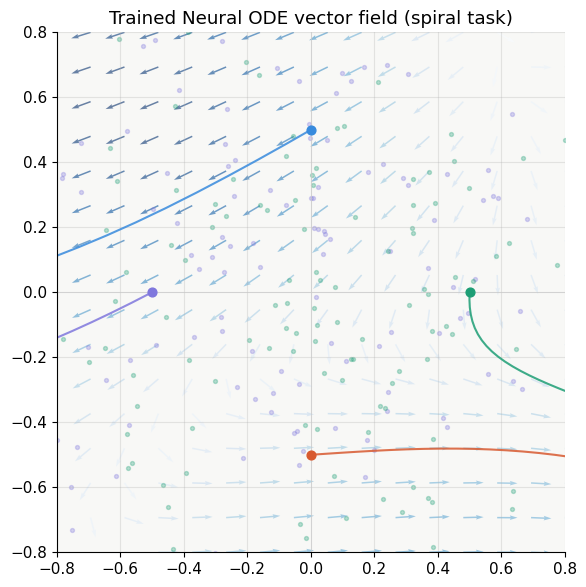

In [11]:
# visualize the trained spiral model's vector field
fig, ax = plt.subplots(figsize=(6, 6))
plot_vector_field(model.ode_func, ax,
                  'Trained Neural ODE vector field (spiral task)',
                  xlim=(-0.8, 0.8), ylim=(-0.8, 0.8), grid=16,
                  traj_starts=[[-0.5, 0.0], [0.5, 0.0], [0.0, -0.5], [0.0, 0.5]])
ax.scatter(X[y==0, 0], X[y==0, 1], c='#7F77DD', s=8, alpha=0.3)
ax.scatter(X[y==1, 0], X[y==1, 1], c='#1D9E75', s=8, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 4 — Limitations: Neural ODE vs ResNet

Neural ODEs are elegant, but come with real tradeoffs. We benchmark them against a comparable ResNet on:
- Training speed (time per epoch)
- Memory usage
- Number of function evaluations (NFE)
- Final accuracy

In [12]:
# comparable ResNet
class ResBlock(nn.Module):
    def __init__(self, dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, dim), nn.Tanh(),
            nn.Linear(dim, dim), nn.Tanh(),
            nn.Linear(dim, 2)
        )

    def forward(self, x):
        return x + self.net(x)  # residual connection


class ResNetClassifier(nn.Module):
    def __init__(self, depth=6):
        super().__init__()
        self.blocks = nn.Sequential(*[ResBlock() for _ in range(depth)])
        self.classifier = nn.Linear(2, 2)

    def forward(self, x):
        return self.classifier(self.blocks(x))


resnet = ResNetClassifier(depth=6).to(device)
print(f'ResNet parameters:     {sum(p.numel() for p in resnet.parameters()):,}')
print(f'Neural ODE parameters: {sum(p.numel() for p in model.parameters()):,}')

ResNet parameters:     26,898
Neural ODE parameters: 4,488


In [13]:
# benchmark: speed, NFE, accuracy
import tracemalloc

def benchmark(m, X, y, epochs=100, label=''):
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()

    if hasattr(m, 'ode_func'):
        m.ode_func.nfe = 0

    # Memory
    tracemalloc.start()

    t0 = time.time()
    for _ in range(epochs):
        opt.zero_grad()
        loss = crit(m(X), y)
        loss.backward()
        opt.step()
    elapsed = time.time() - t0

    _, mem_peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    acc = (m(X).argmax(1) == y).float().mean().item()
    nfe = m.ode_func.nfe if hasattr(m, 'ode_func') else 'N/A'

    print(f'{label:<15} | Time: {elapsed:.2f}s | Acc: {acc:.3f} | '
          f'Peak mem: {mem_peak/1024:.0f} KB | NFE: {nfe}')
    return elapsed, acc, mem_peak / 1024

print('Benchmarking over 100 epochs...\n')
node_time, node_acc, node_mem = benchmark(model, X_dev, y_dev, label='Neural ODE')
res_time, res_acc, res_mem = benchmark(resnet, X_dev, y_dev, label='ResNet')

Benchmarking over 100 epochs...

Neural ODE      | Time: 1.17s | Acc: 0.613 | Peak mem: 38 KB | NFE: 3636
ResNet          | Time: 0.27s | Acc: 0.593 | Peak mem: 36 KB | NFE: N/A


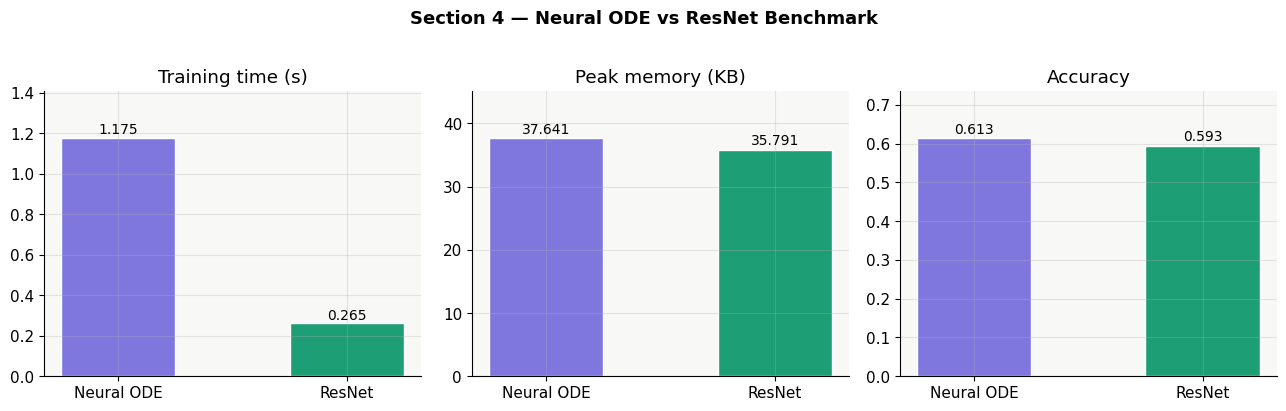


── Qualitative comparison ───────────────────────────────────────────
  Property                  Neural ODE             ResNet
  -----------------------------------------------------------------
  Irregular timestamps      ✓ Native               ✗ Needs padding
  Time interpolation        ✓ Free                 ✗ Not possible
  Adaptive depth            ✓ Automatic            ✗ Fixed layers
  Stiff ODEs                ✗ Slow / unstable      ✓ Not a concern
  Training speed            ✗ Slow (solver)        ✓ Fast
  Parallelism               ✗ Sequential steps     ✓ Parallel layers
  Memory (adjoint)          ✓ O(1) depth           ✗ O(depth)


In [14]:
# comparison charts
metrics = {
    'Training time (s)': [node_time, res_time],
    'Peak memory (KB)':  [node_mem,  res_mem],
    'Accuracy':          [node_acc,  res_acc],
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['#7F77DD', '#1D9E75']

for ax, (metric, vals) in zip(axes, metrics.items()):
    bars = ax.bar(['Neural ODE', 'ResNet'], vals, color=colors, width=0.5, edgecolor='white')
    ax.set_title(metric)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10)
    ax.set_ylim(0, max(vals)*1.2)

plt.suptitle('Section 4 — Neural ODE vs ResNet Benchmark', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Qualitative limitations table
print('\n── Qualitative comparison ───────────────────────────────────────────')
rows = [
    ('Irregular timestamps',  '✓ Native',           '✗ Needs padding'),
    ('Time interpolation',    '✓ Free',              '✗ Not possible'),
    ('Adaptive depth',        '✓ Automatic',         '✗ Fixed layers'),
    ('Stiff ODEs',            '✗ Slow / unstable',   '✓ Not a concern'),
    ('Training speed',        '✗ Slow (solver)',      '✓ Fast'),
    ('Parallelism',           '✗ Sequential steps',  '✓ Parallel layers'),
    ('Memory (adjoint)',      '✓ O(1) depth',         '✗ O(depth)'),
]
print(f'  {"Property":<25} {"Neural ODE":<22} {"ResNet"}')
print('  ' + '-'*65)
for r in rows:
    print(f'  {r[0]:<25} {r[1]:<22} {r[2]}')

---
## Summary

| Section | Key takeaway |
|---|---|
| Spiral classification | Neural ODE learns a smooth, continuous decision boundary |
| Irregular time series | `odeint()` handles arbitrary timestamps natively — no padding needed |
| Vector field | The ODE function defines a learned flow in state space |
| Limitations | More elegant, but slower to train; ResNet wins on raw speed |

**Further reading:**
- Chen et al. (2018) — *Neural Ordinary Differential Equations* (NeurIPS)
- Rubanova et al. (2019) — *Latent ODEs for Irregularly-Sampled Time Series*
- Kidger (2022) — *On Neural Differential Equations* (PhD thesis, comprehensive overview)

**Next steps for your project:**
- Try `method='dopri5'` (adaptive) vs `'rk4'` (fixed) and compare NFE
- Experiment with the adjoint method: `odeint_adjoint` for memory-efficient backprop
- Apply to a real dataset with irregular timestamps (e.g. PhysioNet medical records)